In [1]:
import os
import re
import sys
import math
import sqlite3
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- NEW: Log File Parsing Function ---
def read_ign_log_df(log_path: str, model_name: str = "vehicle_blue") -> Tuple[pd.DataFrame, str]:
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found: {log_path}")

    # Regex to find the model name
    name_regex = re.compile(r"^\s*name:\s*\"" + re.escape(model_name) + r"\"")
    # Regex to find x and y
    x_regex = re.compile(r"^\s*x:\s*(-?[\d\.]+)")
    y_regex = re.compile(r"^\s*y:\s*(-?[\d\.]+)")

    xs, ys = [], []

    found_model = False
    in_position_block = False
    current_x = None

    with open(log_path, 'r') as f:
        for line in f:
            # We are in a 'pose' message, look for our model name
            if not found_model:
                if name_regex.search(line):
                    found_model = True
                continue # Keep searching for the name

            # We found the model, now find its position
            if "position {" in line:
                in_position_block = True
                current_x = None
                continue

            if in_position_block:
                match_x = x_regex.search(line)
                if match_x:
                    current_x = float(match_x.group(1))
                    continue

                match_y = y_regex.search(line)
                if match_y and current_x is not None:
                    xs.append(current_x)
                    ys.append(float(match_y.group(1)))

                    # Reset for the next message in the log
                    found_model = False
                    in_position_block = False
                    current_x = None

    if not xs:
        raise RuntimeError(f"No pose messages found in log file for model: {model_name}")

    # Create a dummy time index
    t_sec = np.arange(len(xs))

    df = pd.DataFrame(dict(t=t_sec, x=xs, y=ys))
    return df, os.path.basename(log_path)


# --- plotting (unchanged) ---
def plot_side_by_side(df_ideal: pd.DataFrame, df_noisy: pd.DataFrame,
                      title_left: str, title_right: str, out_path: Optional[str] = None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

    # Common axis limits
    xmin = min(df_ideal["x"].min(), df_noisy["x"].min())
    xmax = max(df_ideal["x"].max(), df_noisy["x"].max())
    ymin = min(df_ideal["y"].min(), df_noisy["y"].min())
    ymax = max(df_ideal["y"].max(), df_noisy["y"].max())
    dx = xmax - xmin
    dy = ymax - ymin
    pad_x = 0.05 * (dx if dx > 0 else 1.0)
    pad_y = 0.05 * (dy if dy > 0 else 1.0)

    # Ideal
    ax = axes[0]
    ax.plot(df_ideal["x"], df_ideal["y"], color="tab:blue", lw=1.5)
    ax.scatter(df_ideal["x"].iloc[0], df_ideal["y"].iloc[0], c="green", s=30, label="start")
    ax.scatter(df_ideal["x"].iloc[-1], df_ideal["y"].iloc[-1], c="red", s=30, label="end")
    ax.set_title(title_left)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.legend(loc="best")

    # Noisy
    ax = axes[1]
    ax.plot(df_noisy["x"], df_noisy["y"], color="tab:orange", lw=1.5)
    ax.scatter(df_noisy["x"].iloc[0], df_noisy["y"].iloc[0], c="green", s=30, label="start")
    ax.scatter(df_noisy["x"].iloc[-1], df_noisy["y"].iloc[-1], c="red", s=30, label="end")
    ax.set_title(title_right)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.legend(loc="best")

    if out_path:
        # Ensure the directory exists
        os.makedirs(os.path.dirname(os.path.abspath(out_path)), exist_ok=True)
        plt.savefig(out_path, dpi=150)
        print(f"Saved figure to {out_path}")
    plt.show()

# --- UPDATED MAIN PLOTTING FUNCTION ---
def plot_blue_from_logs(ideal_log: str,
                        noisy_log: str,
                        model_name: str = "vehicle_blue",
                        out_path: Optional[str] = None):

    # Use the new log reading function
    df_i, name_i = read_ign_log_df(ideal_log, model_name=model_name)
    df_n, name_n = read_ign_log_df(noisy_log, model_name=model_name)

    left_title = f"Ideal: {name_i} ({model_name})"
    right_title = f"Noisy: {name_n} ({model_name})"
    plot_side_by_side(df_i, df_n, left_title, right_title, out_path=out_path)

Saved figure to /workspaces/585_Probabilistic_Robotics/ros2_motion_noise/outputs/ign_log_side_by_side.png


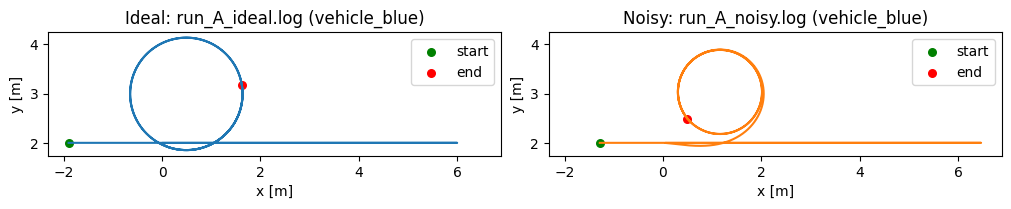

In [2]:
# Set paths to your new log files
ideal_log_file = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/run_A_ideal.log"
noisy_log_file = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/run_A_noisy.log"
out_path = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/outputs/ign_log_side_by_side.png"

# Call the new plotting function
plot_blue_from_logs(ideal_log_file, noisy_log_file,
                      model_name="vehicle_blue",
                      out_path=out_path)